**Used Bike Price Prediction - Feature Engineering and EDA**

**Importing required libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Data Collection and Preparation**

In [2]:
df = pd.read_csv(r"C:\Users\praka\OneDrive\Documents\bikes.csv")
df.head(10)

,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500
5,KTM Duke 200cc 2012,2012,24561 Km,third owner,bangalore,\n\n 35 kmpl,25 bhp,63400
6,Bajaj Pulsar 180cc 2016,2016,19718 Km,first owner,bangalore,\n\n 65 kmpl,17 bhp,55000
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,Mileage 40 Kmpl,first owner,hyderabad,\n\n 40 Kmpl,20.21 bhp,120000
8,KTM Duke 390cc 2018,2018,1350 Km,first owner,jaipur,\n\n 25 kmpl,42.90 bhp,198000
9,Yamaha FZ16 150cc 2014,2014,Mileage 58 Kmpl,first owner,bangalore,\n\n 58 Kmpl,13 bhp,40000


In [3]:
df.shape

(7857, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB


In [5]:
df.columns

Index(['model_name', 'model_year', 'kms_driven', 'owner', 'location',
       'mileage', 'power', 'price'],
      dtype='object')

In [6]:
df.index

RangeIndex(start=0, stop=7857, step=1)

**Finding Missing Values**

In [7]:
print(df.isnull().sum())

model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage       11
power         31
price          0
dtype: int64


In [8]:
dataset = df[df.isnull().any(axis=1)]
print(dataset)

                          model_name  model_year kms_driven         owner  \
135              Hyosung GD250R 2021        2021     185 Km   first owner   
144        TVS Apache RTR 160cc 2014        2014   20372 Km   first owner   
193        Hero Karizma R 223cc 2010        2010   70000 Km   first owner   
422            TVS Apache 150cc 2007        2007   36486 Km  second owner   
1131       Honda CBR 150R 150cc 2014        2014   22500 Km   first owner   
...                              ...         ...        ...           ...   
7442  Hero Splendor Plus 100 CC 2014        2014   15632 Km   first owner   
7513      Bajaj Pulsar NS 200cc 2011        2011   48500 Km   first owner   
7783         Bajaj Pulsar 200cc 2013        2013   25000 Km   first owner   
7796  Hero Splendor Plus 100 CC 2014        2014   10000 Km   first owner   
7801         Hero i Smart 125cc 2016        2016   13800 Km   first owner   

      location       mileage                power   price  
135    chennai 

**Dropping Missing Values and Fixing inconsistent data**

In [9]:
df_cleaned = df[df['location'].notnull()].copy()

In [10]:
df_cleaned.isnull().sum()

model_name     0
model_year     0
kms_driven     0
owner          0
location       0
mileage       11
power         31
price          0
dtype: int64

In [11]:
import re

In [12]:
def clean_mileage(val):
    val = str(val)
    val = re.findall(r'\d+\.\d+|\d+', val)
    return float(val[0]) if val else np.nan

In [13]:
df_cleaned['mileage'] = df_cleaned['mileage'].apply(clean_mileage)

In [14]:
def clean_power(val):
    val = str(val)
    match = re.findall(r'\d+\.\d+|\d+', val)
    return float(match[0]) if match else np.nan

In [15]:
df_cleaned['power'] = df_cleaned['power'].apply(clean_power)

In [16]:
df_cleaned = df_cleaned[~(df_cleaned['mileage'].isnull() & df_cleaned['power'].isnull())]

In [17]:
def clean_kms(val):
    val = str(val)
    val = re.findall(r'\d+', val)
    return int(val[0]) if val else np.nan

In [18]:
df_cleaned['kms_driven'] = df_cleaned['kms_driven'].apply(clean_kms)

In [19]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.reset_index(drop=True, inplace=True)

In [20]:
df_cleaned.shape

(7811, 8)

In [21]:
df_cleaned.isnull().sum()

model_name      0
model_year      0
kms_driven      3
owner           0
location        0
mileage       745
power           4
price           0
dtype: int64

**Checking for correlation**

In [22]:
df_bivariate = df_cleaned.copy()

In [23]:
df_bivariate = df_bivariate[
    (df_bivariate['model_year'] >= 2000) &
    (df_bivariate['kms_driven'] <= 200000) &
    (df_bivariate['price'] > 1000) &
    (df_bivariate['power'] <= 100)
]

In [24]:
corr_matrix = df_bivariate[['price', 'model_year', 'kms_driven', 'mileage', 'power']].corr()


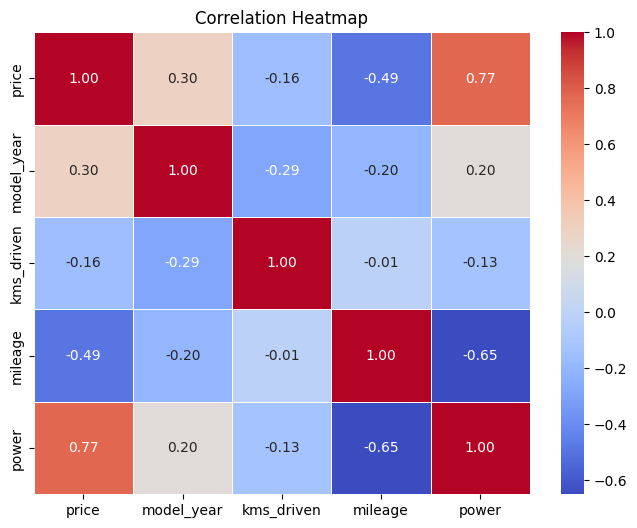

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

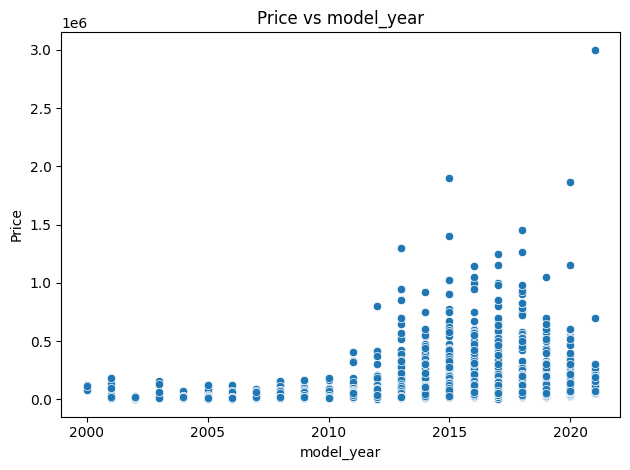

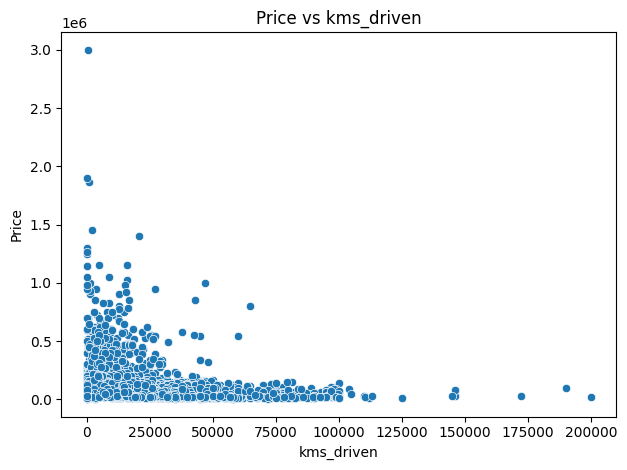

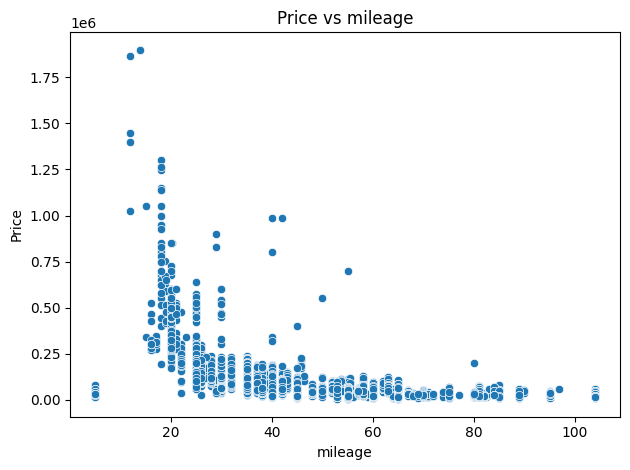

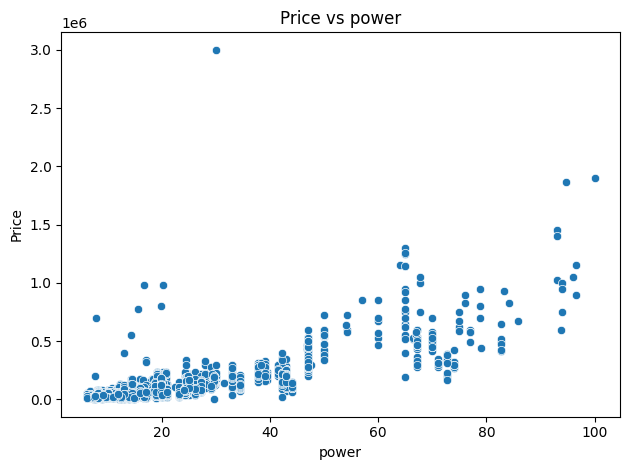

In [26]:
features = ['model_year', 'kms_driven', 'mileage', 'power']
for feature in features:
    plt.figure()
    sns.scatterplot(x=df_bivariate[feature], y=df_bivariate['price'])
    plt.title(f'Price vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

**Checking for outliers**

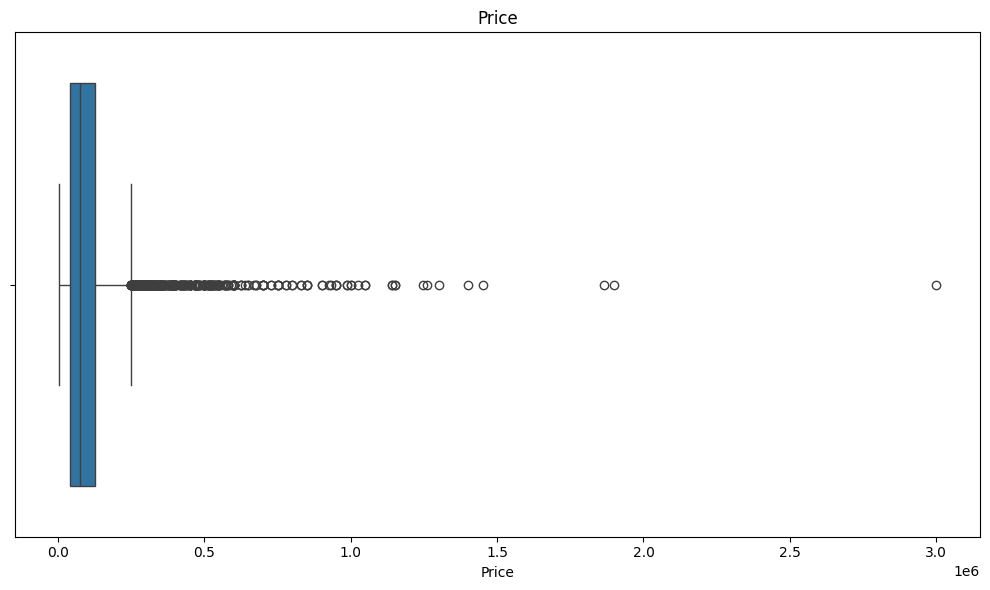

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot( x=df_bivariate['price'])
plt.title('Price')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

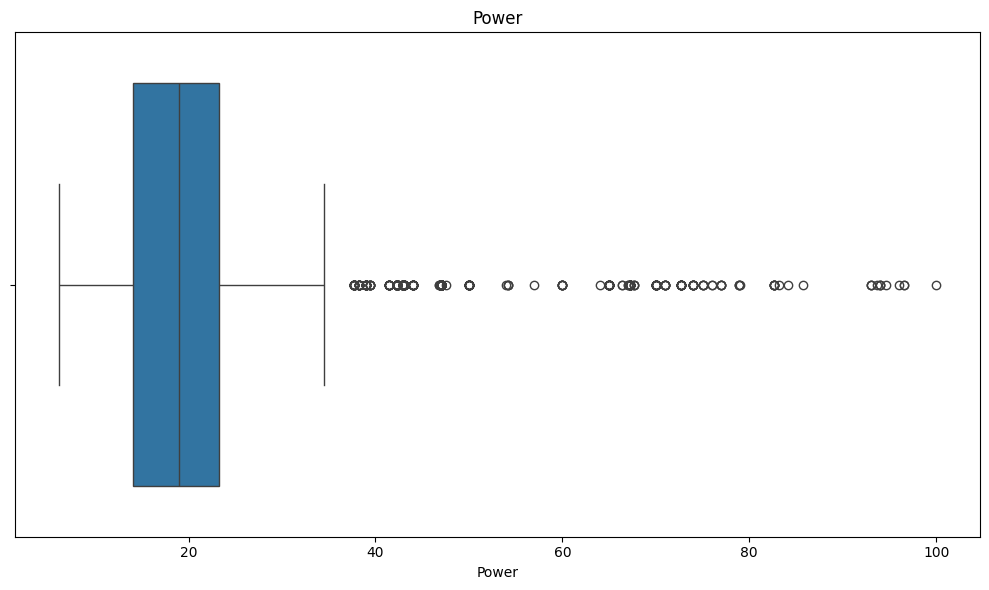

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot( x=df_bivariate['power'])
plt.title('Power')
plt.xlabel('Power')
plt.tight_layout()
plt.show()

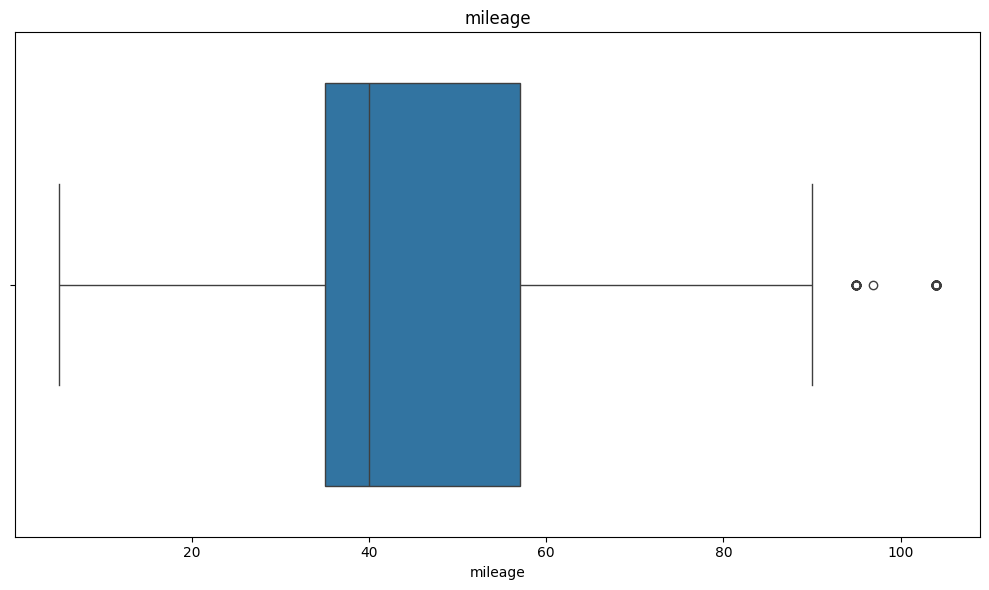

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot( x=df_bivariate['mileage'])
plt.title('mileage')
plt.xlabel('mileage')
plt.tight_layout()
plt.show()

**Removing Outliers**

In [30]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]


In [31]:
for col in ['price', 'power', 'kms_driven', 'mileage']:
    df_bivariate = remove_outliers_iqr(df_bivariate, col)

print("Shape after removing outliers:", df_bivariate.shape)

Shape after removing outliers: (5999, 8)


In [32]:
df_bivariate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5999 entries, 0 to 7810
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model_name  5999 non-null   object 
 1   model_year  5999 non-null   int64  
 2   kms_driven  5999 non-null   float64
 3   owner       5999 non-null   object 
 4   location    5999 non-null   object 
 5   mileage     5999 non-null   float64
 6   power       5999 non-null   float64
 7   price       5999 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 421.8+ KB


**Feature Engineering**

In [33]:
df_fe = df_bivariate.copy()

# 1. Extract brand from model_name (first word)
df_fe['brand'] = df_fe['model_name'].str.split().str[0]

# 2. Create bike age from model_year
df_fe['bike_age'] = 2025 - df_fe['model_year']

# 3. Handle missing 'owner' values
df_fe['owner'].fillna(df_fe['owner'].mode()[0], inplace=True)


C:\Users\praka\AppData\Local\Temp\ipykernel_14152\391461392.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe['owner'].fillna(df_fe['owner'].mode()[0], inplace=True)


In [34]:
import re, numpy as np
# -------- ENGINE SIZE (cc) -----------
def extract_cc(txt):
    m = re.search(r'(\d+)\s*cc', str(txt).lower())
    return int(m.group(1)) if m else np.nan

df_fe['engine_cc'] = df_fe['model_name'].apply(extract_cc)
df_fe['engine_cc'].fillna(df_fe['engine_cc'].median(), inplace=True)

C:\Users\praka\AppData\Local\Temp\ipykernel_14152\2121230195.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe['engine_cc'].fillna(df_fe['engine_cc'].median(), inplace=True)


In [35]:
# -------- POWER‑TO‑WEIGHT -----------
df_fe['pwr_to_weight'] = df_fe['power'] / df_fe['engine_cc']
df_fe['pwr_to_weight'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_fe['pwr_to_weight'].fillna(df_fe['pwr_to_weight'].median(), inplace=True)

C:\Users\praka\AppData\Local\Temp\ipykernel_14152\919577675.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe['pwr_to_weight'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\praka\AppData\Local\Temp\ipykernel_14152\919577675.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

target = 'price'
cat_cols = ['brand', 'location', 'owner']
num_cols = ['mileage', 'power', 'kms_driven', 'bike_age',
            'engine_cc', 'pwr_to_weight']

X = df_fe[cat_cols + num_cols]
y = df_fe[target]

In [37]:
# pipeline: one‑hot for cats, standard scale nums
ct = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
X_train_ct = ct.fit_transform(X_train)
X_test_ct  = ct.transform(X_test)

C:\pythonProject\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [38]:
df_fe_final = df_fe.drop(columns=['model_name', 'model_year', 'location', 'brand'])

In [39]:
# Check the cleaned and engineered data
print(df_fe_final.head())

   kms_driven        owner  mileage  power   price  bike_age  engine_cc  \
0     17000.0  first owner     35.0  19.00   63500         8      180.0   
1     50000.0  first owner     35.0  19.80  115000         9      350.0   
5     24561.0  third owner     35.0  25.00   63400        13      200.0   
6     19718.0  first owner     65.0  17.00   55000         9      180.0   
7        40.0  first owner     40.0  20.21  120000         5      180.0   

   pwr_to_weight  
0       0.105556  
1       0.056571  
5       0.125000  
6       0.094444  
7       0.112278  


**Data Visualization**

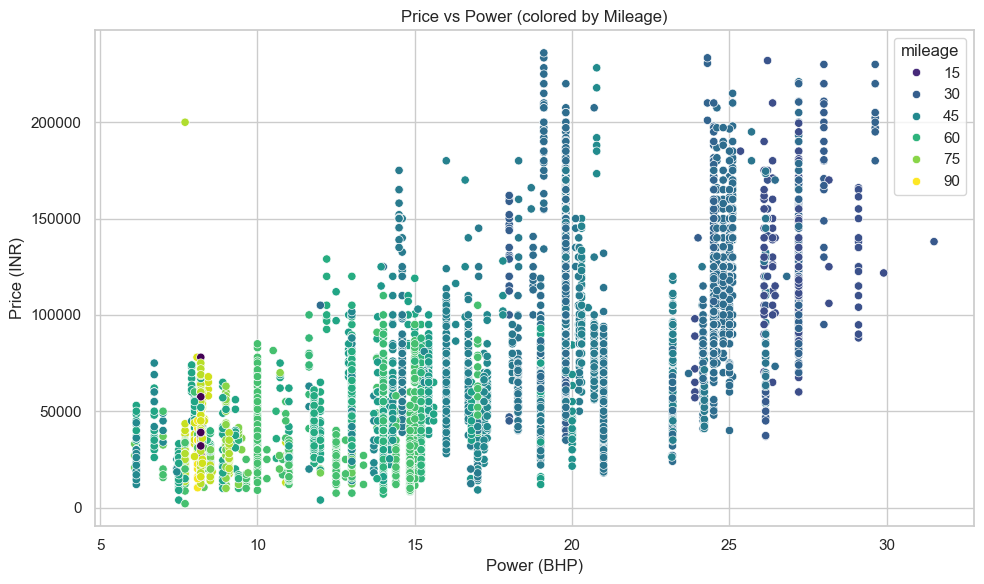

In [40]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Multivariate: Power vs Price (hue = Mileage)
plt.figure()
sns.scatterplot(data=df_fe, x='power', y='price', hue='mileage', palette='viridis')
plt.title('Price vs Power (colored by Mileage)')
plt.xlabel('Power (BHP)')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

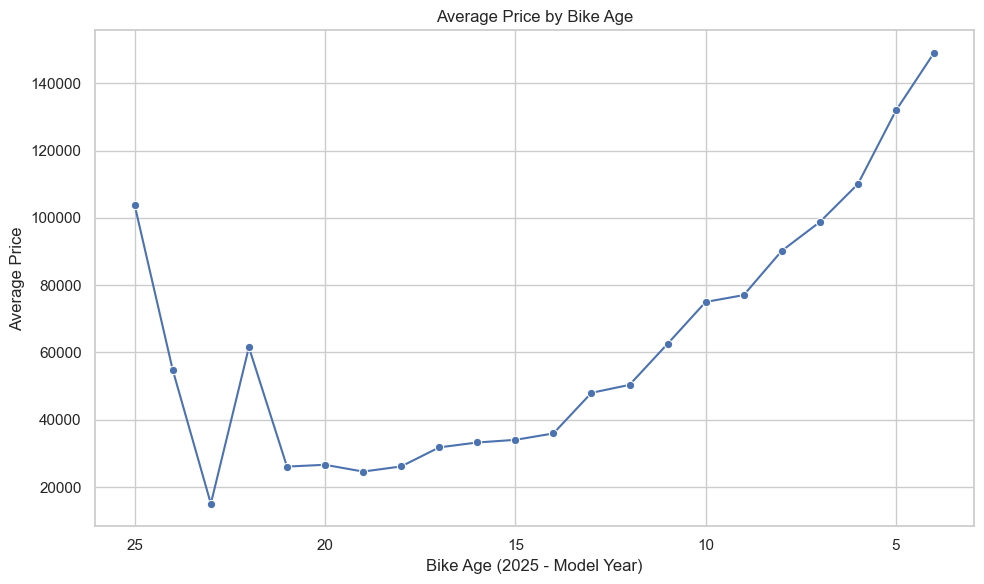

In [41]:
# 2. Time Series: Average price by Bike Age
price_by_age = df_fe.groupby('bike_age')['price'].mean().reset_index()

plt.figure()
sns.lineplot(data=price_by_age, x='bike_age', y='price', marker='o')
plt.title('Average Price by Bike Age')
plt.xlabel('Bike Age (2025 - Model Year)')
plt.ylabel('Average Price')
plt.gca().invert_xaxis()  # Newer bikes on left
plt.tight_layout()
plt.show()

C:\Users\praka\AppData\Local\Temp\ipykernel_14152\3703916691.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_locations.values, y=top10_locations.index, palette='crest')


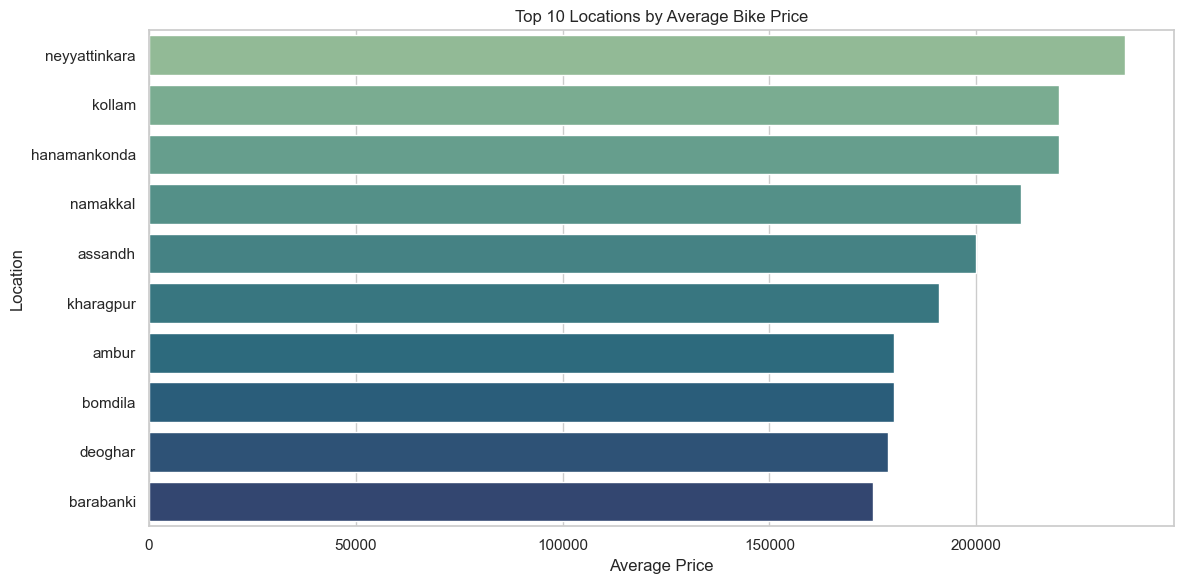

In [42]:
# Top 10 locations with highest average bike price
top10_locations = df_fe.groupby('location')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10_locations.values, y=top10_locations.index, palette='crest')
plt.title('Top 10 Locations by Average Bike Price')
plt.xlabel('Average Price')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

**Model Building**

In [43]:
def map_owner(val):
    val = str(val).lower()
    if 'first owner' in val: return 1
    elif 'second owner' in val: return 2
    elif 'third owner' in val: return 3
    elif 'fourth owner or more' in val: return 4
    else: return np.nan

df_fe['owner'] = df_fe['owner'].apply(map_owner)

In [44]:
# Drop non-numeric or text columns
df_model = df_fe.drop(columns=['model_name', 'model_year', 'location', 'brand'])

In [45]:
# Fill missing values with median
df_model = df_model.fillna(df_model.median(numeric_only=True))

In [46]:
# Check the final shape
print("Final shape:", df_model.shape)
print("Any nulls?\n", df_model.isnull().sum())# Check the final shape


Final shape: (5999, 8)
Any nulls?
 kms_driven       0
owner            0
mileage          0
power            0
price            0
bike_age         0
engine_cc        0
pwr_to_weight    0
dtype: int64


In [47]:
# Step 5.2: Define features and target
X = df_model.drop(columns=['price'])
y = df_model['price']


In [48]:
print(df_model.isnull().sum())

kms_driven       0
owner            0
mileage          0
power            0
price            0
bike_age         0
engine_cc        0
pwr_to_weight    0
dtype: int64


In [49]:
df_model.shape

(5999, 8)

In [50]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

models = {
    'LinearRegression': LinearRegression(),
    'Lasso':            Lasso(alpha=0.1, max_iter=5000),
    'RandomForest':     RandomForestRegressor(n_estimators=300,
                                              random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(X_train_ct, y_train)
    preds = m.predict(X_test_ct)
    results[name] = {
        'R²':  round(r2_score(y_test, preds), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 1)
    }

pd.DataFrame(results).T.sort_values('R²', ascending=False)

,R²,RMSE
RandomForest,0.890,15286.0
GradientBoosting,0.886,15536.6
Lasso,0.818,19684.2
LinearRegression,0.816,19743.1


In [51]:
# Lightweight manual tuning instead of full GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

best_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

best_rf.fit(X_train_ct, y_train)
rf_preds = best_rf.predict(X_test_ct)

print("Tuned RandomForest R²:", round(r2_score(y_test, rf_preds), 3))
print("Tuned RandomForest RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_preds)), 1))


Tuned RandomForest R²: 0.892
Tuned RandomForest RMSE: 15134.8


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only numeric features
num_features = ['mileage', 'power', 'kms_driven', 'bike_age', 'engine_cc', 'pwr_to_weight']

# Get indices of numeric features from ColumnTransformer
num_idx = ct.transformers_[1][2]  # index of numeric features in the ColumnTransformer

# Extract corresponding importances from model
importances = best_rf.feature_importances_
num_importances = importances[-len(num_features):]  # assumes numeric features come last in transformer

C:\Users\praka\AppData\Local\Temp\ipykernel_14152\554684715.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=num_importances, y=num_features, palette='viridis')


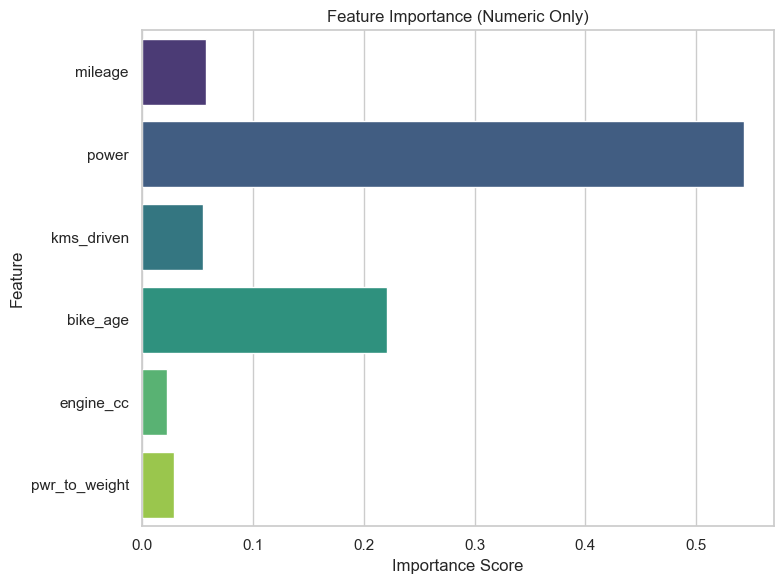

In [53]:

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=num_importances, y=num_features, palette='viridis')
plt.title("Feature Importance (Numeric Only)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()